In [1]:
import os
import math
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADVisualizer   import CADVisualizer
from Pred_NN_Classes import PPNet
from Decoder_CLasses.VoronoiDecorder import VoronoiDecoder,VoronoiModelVisualizer,ExactUVVoronoi
from Training.MainTrain import TrainingConfig, NN_Trainer, Load_Model
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)


gmesh was loaded successfully!
Code Directory: /home/arash/HVD_Shell_SF
Test Step files Directory: /home/arash/HVD_Shell_SF/Testparts
device: cuda
PyVista backend: trame


In [2]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
ConeTaped = TesPartsDir / "ConeTaped.stp"
FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
Planar = TesPartsDir / "Planar.stp"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"
FreeFormSurf4 = TesPartsDir / "FreeForm4.stp"
FreeFormBench = TesPartsDir / "FreeFormBench.stp"
FreeSharp1 = TesPartsDir / "FreeSharp1.stp"
FreeSharp2 = TesPartsDir / "FreeSharp2.stp"
SeatBr = TesPartsDir / "SeatBr.stp"
MouseBot = TesPartsDir / "MouseBot.stp"

shape_path = FreeSharp1

# Meshing controls
# OCC meshing (global fallback for mode="mesh"):
#   - deflection: smaller -> finer OCC mesh
#   - angle: smaller -> finer OCC mesh on curved regions
# Manual UV-grid meshing (used when freeform_mesher="manual" on supported analytic faces):
#   - n_u, n_v: more samples -> finer UV grid mesh
# Gmsh meshing (used for free-form faces when freeform_mesher is "auto" or "gmsh"):
#   - gmsh_size_scale: smaller -> finer mesh, larger -> coarser mesh
#   - gmsh_algorithm: picks the Gmsh 2D meshing algorithm (6 is a solid default)
# Mesher selection:
#   - freeform_mesher="auto": try Gmsh first, then fall back to OpenCascade
#   - freeform_mesher="gmsh": require Gmsh for free-form faces
#   - freeform_mesher="manual": use UV-grid on supported analytic faces, otherwise OpenCascade

Case_name = shape_path.stem
print(Case_name)
generator = CADTensorGenerator(
    deflection=0.001,
    angle=0.001,
    metric_tol=1e-9,
    det_min=1e-5,
    n_u=30  ,
    n_v=30,
    freeform_mesher="auto",   #"auto"
    gmsh_size_scale=0.2,
    gmsh_algorithm=6,
    device=device,
    selected_face_index=0,
)

mesh_df, faces_df, tensors = generator.generate_from_file(
    shape_path=str(shape_path),
    input_ring=1,
    mode="mesh", #"1: mesh" "2:Sampled_points "
    M_per_face=2000,
    pool_size_factor=10,
    fps_pool_factor=4,
    use_fps=True,
    triangulation_max_edge_rel=0.1,
)
uv = tensors["uv"]
Xu = tensors["Xu"]
Xv = tensors["Xv"]
points_xyz = tensors["points_xyz"]
face_areas = tensors["face_areas"]
faces_ijk = tensors["faces_ijk"]
face_id = tensors["face_id"]
boundary_idx_ring1 = tensors["boundary_idx_ring1"]
pv_faces = tensors["pv_faces"]

face_tensor = tensors["face_tensors"][0]
face_u_periodic = bool(face_tensor["u_periodic"])
face_v_periodic = bool(face_tensor["v_periodic"])

bbx_all = list(tensors["BBX"].values())
xmin = min(b["xmin"] for b in bbx_all)
xmax = max(b["xmax"] for b in bbx_all)
ymin = min(b["ymin"] for b in bbx_all)
ymax = max(b["ymax"] for b in bbx_all)
zmin = min(b["zmin"] for b in bbx_all)
zmax = max(b["zmax"] for b in bbx_all)

dx = xmax - xmin
dy = ymax - ymin
dz = zmax - zmin

print(f"Selected CAD face index: {generator.selected_face_index}")
print(f"Number of faces used: {tensors['num_faces']}")
print(f"Number of sampled points: {uv.shape[0]}")
print(f"Selected-face BBX dimensions: dx={dx:.4f}, dy={dy:.4f}, dz={dz:.4f}")

if face_u_periodic:
    print("Face is periodic in u direction")
if face_v_periodic:
    print("Face is periodic in v direction")

viz.visualize_show_Model(points_xyz, pv_faces)

pts = points_xyz.detach().cpu().numpy()
cloud = pv.PolyData(pts)
plotter = pv.Plotter()
plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=6)
plotter.show()


FreeSharp1
Model is meshed using Gmsh tool
MinVolFrac: 0.047724075615406036
Mesh edge length: min=0.0841765 max=0.173434 median=0.128297
Selected CAD face index: 0
Number of faces used: 1
Number of sampled points: 18903
Selected-face BBX dimensions: dx=17.0361, dy=9.1413, dz=10.5274


Widget(value='<iframe src="http://localhost:33443/index.html?ui=P_0x71fe28652b00_0&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:33443/index.html?ui=P_0x71ffd34c74f0_1&reconnect=auto" class="pyvi…

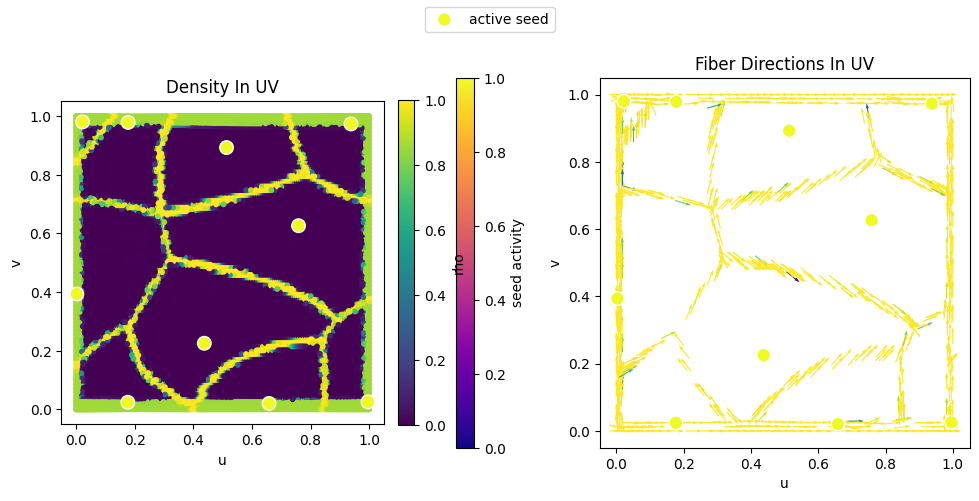

Widget(value='<iframe src="http://localhost:33443/index.html?ui=P_0x71fb86f2d2d0_17&reconnect=auto" class="pyv…

In [18]:
#Voronoi visualization
from torch import tensor


RUN_THIS = True
if  RUN_THIS:
    seeds_raw= torch.tensor([

        [0.9, 0.20],
        [0.9, 0.40],
        [0.9, 0.60],
        [0.9, 0.80],


    ], dtype=torch.float32)

    seeds_raw = torch.tensor([
       [0.245, 0.586],
        [0.322, 0.583],
        [0.395, 0.546],
        [0.458, 0.490],
        [0.397, 0.434],
        [0.317, 0.344],
        [0.247, 0.344],
        [0.852, 0.508],
        [0.855, 0.444],
    ], dtype=torch.float32)
    seeds_raw = torch.tensor([
        [0.8568, 0.7984],
        [0.3155, 0.1731],
        [0.1516, 0.8967],
        [0.9806, 0.0420],
        [0.6695, 0.0536],
        [0.9605, 0.9759],
        [0.4073, 0.8828],
        [0.0606, 0.2212],
        [0.5049, 0.8808],
        [0.8558, 0.1468],]
        ,dtype = torch.float32)
    
    # S = 20
    # margin = 0
    # seeds_raw = margin + (1 - 2 * margin) * torch.rand((S, 2), dtype=torch.float32)
    #seeds_raw = generator.fps(uv, K=10, M=10, return_indices=False).cpu()  # FPS seeds from the input UV points
    N= 10
    seeds_raw_index= generator.fps_3d(points_xyz,N,boundary_idx_ring1)
    seeds_raw = uv[seeds_raw_index]

    # face_idx = 0
    # face_tensor = tensors["face_tensors"][face_idx]
    # seeds_raw = result["best_seeds"][face_idx]
    # seeds_raw = result["best_seeds"][face_idx]
    #print("seeds_raw:", seeds_raw)
    S = seeds_raw.shape[0]
    # symmetric pairwise widths
    w_raw = torch.full((S, S), -10.05 ,dtype=torch.float32)
    # w_raw = (torch.rand(S, S) * 40) - 20
    # w_raw =  0.5*(w_raw + w_raw.T)
    #print(w_raw)


    # optional anisotropy

    theta = 2 * torch.pi * torch.rand(S, dtype=torch.float32)
    a_raw = 3* torch.randn(S, dtype=torch.float32)
    # theta = None
    # a_raw = None



    face_tensor = tensors["face_tensors"][0]   # choose the face you want to test

    uv = face_tensor["uv"]
    Xu = face_tensor["Xu"]
    Xv = face_tensor["Xv"]
    points_xyz = face_tensor["points_xyz"]
    faces_ijk = face_tensor["faces_ijk"]

    Veron_viz = VoronoiModelVisualizer.from_face_tensor(
        face_tensor,
        tau=0.01,
        n_seeds=S,
        seed_domain_temp=0.02,
        seed_domain_mask_threshold=0.5,
        use_metric_anisotropy=True,
        beta=0.003,
        density_projection_strength=0.45,
        density_projection_threshold=0.35,
        density_projection_gamma=0.06,
        w_min=0.005,
        w_max_ratio=0.25,
        fixed_height=0.3,
        use_boundary_attachment=True,
        boundary_attach_width_min=1e-6,
        boundary_attach_width_max=2e-2,
        raw_temp=0.01,
        seed_activity_sharpness= 60,
    )
    result = Veron_viz.visualize_fields(
        seeds_raw=seeds_raw,
        w_raw=w_raw,
        theta=theta,
        a_raw=a_raw,
        boundary_width_raw=torch.tensor(1.0),
        boundary_alpha_raw=torch.tensor(1),
        boundary_beta_raw=torch.tensor(0.0),
        show_uv=True,
        show_3d=True,
        fiber_stride=5,
        fiber_scale_uv=0.05,
        fiber_scale_3d=0.5,
        fiber_min_strength=0.7,
        show_fiber_density_background=False,
        hard_seed_mask=False,
    )

    display(result["uv_fig"])
    result["plotter"].show()


In [ ]:

Include_FEM= True
LoadingCase = "Torsion in Y"  # "Tensile" or "Compression"

voxel_size = (dx+dy+dz)/50
fixed_height_shell= voxel_size*2
tangential_tol = voxel_size*0.8

if(Include_FEM):
    # ============================================================
    # Choose ONE load case below.
    # Comment out the other two sections.
    # ============================================================


    # ------------------------------------------------------------
    # 1) Tensile / Compression
    # ------------------------------------------------------------
    # Use this when you want to pull or push the shell along one axis.
    #
    # load_case:
    #   "tensile_compression", "tensile", or "compression"
    #
    # BC_dir:
    #   Axis of loading: "x", "y", or "z".
    #   The min side of this axis is fixed.
    #   The max side of this axis receives the force.
    #
    # Load_magnitude:
    #   Positive value pulls in +BC_dir direction.
    #   Negative value pushes/compresses in -BC_dir direction.
    #
    # # Example:
    shell_problem = ThickenShell(
        thickness=fixed_height_shell,
        BC_dir="x",
        Load_magnitude=0.1,
        voxel_size=voxel_size,
        extra_layers=1,
        tensors=tensors,
        tangential_tol=tangential_tol,
        load_case="tensile_compression",
    )


    # ------------------------------------------------------------
    # 2) Three-Point Bending
    # ------------------------------------------------------------
    # Use this when you want two supports at the ends and a load in the middle.
    #
    # load_case:
    #   "three_point_bending", "threepoint_bending", or "3_point_bending"
    #
    # BC_dir:
    #   Span direction of the part.
    #   Supports are placed at min and max sides of this axis.
    #   The load is applied near the middle of this axis.
    #
    # load_dir:
    #   Direction of the bending force: "x", "y", or "z".
    #
    # Load_magnitude:
    #   Force applied at the middle.
    #   Sign controls direction along load_dir.
    #
    # load_surface_dir:
    #   Optional. Restricts the middle load nodes to one outer surface.
    #   Example: load_surface_dir="z", load_surface_side="max"
    #   means apply the middle force only on the top z surface.
    #
    # load_surface_side:
    #   "min" or "max" side of load_surface_dir.
    #
    # Example:
    # shell_problem = ThickenShell(
    #     thickness=fixed_height_shell,
    #     BC_dir="x",
    #     Load_magnitude=-0.1,
    #     voxel_size=voxel_size,
    #     extra_layers=1,
    #     tensors=tensors,
    #     tangential_tol=tangential_tol,
    #     load_case="three_point_bending",
    #     load_dir="z",
    #     load_surface_dir="z",
    #     load_surface_side="max",
    # )


    # ------------------------------------------------------------
    # 3) Torsion / Twist
    # ------------------------------------------------------------
    # Use this when you want to twist the shell around one axis.
    #
    # load_case:
    #   "torsion", "twist", or "torque"
    #
    # BC_dir:
    #   Axis of twisting: "x", "y", or "z".
    #
    # fixed_side:
    #   Which end of BC_dir is fixed: "min" or "max".
    #
    # force_side:
    #   Which end receives the torque.
    #   Must be opposite to fixed_side.
    #   If omitted, the code automatically chooses the opposite side.
    #
    # Load_magnitude:
    #   Total torque magnitude.
    #   Sign controls twist direction.
    #
    # Example:
    # shell_problem = ThickenShell(
    #     thickness=fixed_height_shell,
    #     BC_dir="y",
    #     Load_magnitude=0.1,
    #     voxel_size=voxel_size,
    #     extra_layers=1,
    #     tensors=tensors,
    #     tangential_tol=tangential_tol,
    #     load_case="torsion",
    #     fixed_side="min",
    #     force_side="max",
    # )

    # shell_problem =None
    # fem =None
    fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)
    shell_problem.debug_voxel_stats()
    loading_img = shell_problem.show_voxels_surface_and_bc(
        return_img=True,
        off_screen=True,
        window_size=(560, 430),
        show=True,
    )
else:
    shell_problem = None
    fem = None
    loading_img = None   

In [ ]:
Explanation = "_TTorsion_Y"

cfg = TrainingConfig(
    # Case / Reproducibility
    LoadingCasee=LoadingCase,
    training_face_index=0,
    seed_number=10,
    use_Metric_anisotropy=False,
    fixed_height=0.5,
    target_volfrac=0.25,

    # Seed Initialization / Geometry
    seed_repulsion_sigma=0.1,
    boundary_margin=0.05,

    # Training Loop
    num_steps=500,
    log_every=100,
    early_stop_start=0.5,
    patience=1000,
    min_delta=1e-10,

    # Plateau / Pruning
    prune_inactive_on_plateau=False,
    prune_patience=300,

    # Width Parameters
    freeze_w=False,
    w_const=0.1,
    w_min=0.05,
    min_feature_size_3d=0.4,
    auto_update_wmin=False,
    w_max_ratio=0.3,
    duplicate_merge_sigma=0.05,

    # Fiber Band Priors
    use_band_weighted_fiber_pairs=True,
    fiber_band_prior_power=2.0,
    fiber_band_prior_floor=0.02,

    # Hollow / Edge Density
    hollow_void_threshold=0.85,
    hollow_edge_threshold=0.45,
    hollow_temp=0.05,
    hollow_rho_edge_min=0.75,

    # Seed Activity
    seed_activity_sharpness=1.5,
    seed_activity_threshold=0.4,
    lam_seed_active=100.0,
    min_active_seeds=2,

    # Boundary Attachment
    use_boundary_attachment=True,
    predict_boundary_params=False,
    boundary_volume_assist=0.0,
    boundary_attach_width=0.001,
    boundary_attach_beta=0.003,
    boundary_attach_alpha=1.0,
    boundary_attach_width_min=5e-6,
    boundary_attach_width_max=5e-5,
    boundary_attach_alpha_min=0.05,
    boundary_attach_alpha_max=1.0,
    boundary_attach_beta_min=0.003,
    boundary_attach_beta_max=0.05,

    # Tau / Temperature
    predict_tau=None,
    tau=0.02,
    tau_pred_start=0.1,
    tau_pred_min=1e-3,
    tau_pred_max=1.0,
    tau_anneal_final=0.03,
    tau__anneal_final=0.03,
    tau_anneal_start_frac=0.0,
    tau_anneal_ramp_frac=0.5,
    beta=0.01,

    # Density Projection
    density_projection_strength=0.8,
    density_projection_threshold=0.75,
    density_projection_gamma=0.04,

    # Rolling Seed Anchors
    use_rolling_seed_anchors=True,
    seed_anchor_momentum=0.08,
    seed_anchor_warmup_frac=0.005,

    # Anchor Guards
    guard_seed_anchor_updates=False,
    anchor_guard_rep_max=0.30,
    anchor_guard_bnd_max=0.80,
    anchor_guard_vol_eff_min=0.10,
    anchor_guard_width_factor_min=1.20,
    anchor_guard_min_seed_dist_factor=2.0,

    # Seed Spacing / Projection
    collapse_min_seed_dist_factor=2,
    project_seed_spacing_each_step=False,
    seed_projection_iters=4,

    # Seed Domain Handling
    allow_seed_outside_domain=True,
    allow_seed_outside_domain_warmup_frac=0.1,
    seed_domain_margin=0.35,
    use_seed_domain_mask=True,
    seed_domain_mask_threshold=0.5,
    seed_domain_temp=0.05,
    seed_domain_mask_support_scale=2.5,
    seed_domain_mask_max_points=2048,

    # Seed Offset Schedule
    Offset_scale=0.5,
    use_independent_seed_offsets=True,
    independent_seed_offset_max=0.05,
    seed_offset_scale_start=0.5,
    seed_offset_scale_final=0.25,
    seed_offset_scale_ramp_frac=1.0,

    # Loss Weights
    lam_fem=50,
    lam_vol=30,
    lam_rep=0,
    lam_bnd=0,
    lam_strut=0.0,
    lam_strut_edge=1.0,
    lam_strut_void=3.0,
    lam_width_active=0,

    # Width Targeting
    width_target_frac=0.04,
    width_target_sparse_boost=1.0,
    width_target_frac_max=0.1,
    width_warmup_start_frac=0,
    width_warmup_ramp_frac=0,
    lam_width_active_hard_multiplier=1.0,
    decoder_raw_temp=1.25,
    w_head_bias_init=None,

    # Loss Normalization / FEM Stability
    comp_normalize_by=None,
    normalize_losses=False,
    fem_density_floor=0.005,
    skip_bad_fem_steps=True,

    # Hard Refine Phase
    hard_refine_start_frac=0.95,
    freeze_tau_head_during_hard_refine=True,
    hard_refine_width_multiplier=1.0,

    # Boundary-Weighted / Effective Volume
    use_boundary_weighted_volume=False,
    boundary_vol_weight=0.2,
    effective_volume_power=2.0,
    lam_vol_effective=4,
    lam_vol_sharp=1,
    sharp_vol_start_frac=0.9,
    sharp_vol_ramp_frac=0.3,

    # Learning Rates
    lr_seed_refine=1e-4,
    lr_independent_seed_offsets=1e-3,
    lr_delta_head=1e-4,
    lr_mlp=1e-4,
    lr_w_head=5e-5,
    lr_h_head=1e-4,
    lr_boundary_heads=1e-4,

    # Numerical / Optimizer Settings
    eps=1e-12,
    scheduler_milestones=(0.75, 0.9),
    scheduler_gamma=0.2,
    save_fem_debug_history=True,
    grad_clip_norm=1.0,

    # TensorBoard Logging
    tensorboard_enabled=True,
    tensorboard_log_root="runs",
    experiment_name=f"{Case_name}{Explanation}",
    tb_flush_secs=10,
    tb_log_histograms_every=100,

    # Timelapse Output
    MakeTimelaps=True,
    timelapse_output_folder=f"Case_Studies/{Case_name}{Explanation}",
    timelapse_frame_step=10,
    TM_laps_res_u=100,
    TM_laps_res_v=100,
    TM_laps_Thr=0.3,
    debug_anomaly_detection=False,
)

trainer = NN_Trainer(
    generator=generator,
    viz=viz,
    decoder_cls=VoronoiDecoder,
    ppnet_cls=PPNet,
    fem=fem,
    shell_problem=shell_problem,
    config=cfg,
    loading_img=loading_img,
)

print(cfg)

result = trainer.train(
    shape_path,
    face_tensors=tensors["face_tensors"],
)
trainer.visualize_result_stepwise(result, points_xyz, faces_ijk)
threshold= 0.75
trainer.visualize_result_final(result, points_xyz, faces_ijk, thr=threshold, show_solid=False)
trainer.Visualize_fresult_final_fiber_Direction_3D( result, points_xyz,faces_ijk,thr=threshold)
out = trainer.visualize_result_final_fiber_direction_2d(result, points_xyz, faces_ijk,thr=threshold)
display(out["figure"])
trainer.visualize_best_seed_activity(result, points_xyz, faces_ijk)

In [ ]:
Doit_again = False
if(Doit_again):
    threshold= 0.75
    trainer.visualize_result_final(result, points_xyz, faces_ijk, thr=threshold, show_solid=False)
    trainer.Visualize_fresult_final_fiber_Direction_3D( result, points_xyz,faces_ijk,thr=threshold)
    out = trainer.visualize_result_final_fiber_direction_2d(result, points_xyz, faces_ijk,thr=threshold)
    display(out["figure"])
    trainer.visualize_best_seed_activity(result, points_xyz, faces_ijk)
    #trainer.visualize_result_final_smooth_surface_pyvista(result, points_xyz, faces_ijk, thr=0.5)
    #print(result["tensorboard_log_dir"])


In [ ]:
Load_Model_again = True
if(Load_Model_again):
    viz = CADVisualizer()
    # Laoding model and extracting mesh and tensors as input
    FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
    FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
    FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
    ConeTaped = TesPartsDir / "ConeTaped.stp"
    FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
    Planar = TesPartsDir / "Planar.stp"
    YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
    CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
    Cube           = TesPartsDir / "Cube.stp"
    CircularSur2   = TesPartsDir / "CircularSur2.stp"
    Conic          = TesPartsDir / "Conic.stp"
    CircularHoles  = TesPartsDir / "CircularHoles.stp"
    FullCylinder   = TesPartsDir / "FullCylinder.stp"
    Sphere         = TesPartsDir / "Sphere.stp"
    SphereTap      = TesPartsDir / "SphereTap.stp"
    Tidebottle     = TesPartsDir / "Tidebottle.STEP"

    #shape_path = FreeFormCLosed

    Case_name = shape_path.stem
    print(Case_name)
    generator = CADTensorGenerator(
        deflection=0.001,
        angle=0.001,
        metric_tol=1e-9,
        det_min=1e-5,
        n_u=30  ,
        n_v=30,
        freeform_mesher="auto",   #"auto"
        gmsh_size_scale=0.3,
        gmsh_algorithm=6,
        device=device,
        selected_face_index=0,
    )

    mesh_df, faces_df, tensors = generator.generate_from_file(
        shape_path=str(shape_path),
        input_ring=1,
        mode="mesh", #"1: mesh" "2:Sampled_points "
        M_per_face=2000,
        pool_size_factor=10,
        fps_pool_factor=4,
        use_fps=True,
        triangulation_max_edge_rel=0.1,
    )

In [ ]:
if(Load_Model_again):
    from Training.MainTrain import Load_Model
    ParamPath = result["optimized_function_path"]
    OptimizedFunction= Load_Model.load(
        path=ParamPath,
        device=device,
    )
    Fields_Main = Load_Model.evaluate(OptimizedFunction, tensors)

    # Fig2D = Load_Model.visualize_2d(fields=Fields_Main,fiber_stride=10,fiber_min_density=0.7)
    # display(Fig2D)
    Plotter1,VOlFrac_main = Load_Model.visualize_3d(fields=Fields_Main,fiber_stride=10,fiber_min_density=0.7,fiber_scale_3d = 0.25, fiber_color =  "#000000bc")
    Plotter1.add_text("Optimized Density Field", font_size=12)
    Plotter1.show()
    Thr_Val = 0.8
    Field_Binary= Load_Model.binarize(fields = Fields_Main, density_threshold=Thr_Val)
    # Fig2D = Load_Model.visualize_2d(fields=Field_Binary,fiber_stride=10,fiber_min_density=0.7)
    # display(Fig2D)
    Plotter2,VOlFrac_Binary= Load_Model.visualize_3d(fields=Field_Binary,fiber_stride=10,fiber_min_density=0.7,fiber_scale_3d = 0.25, fiber_color =  "#000000bc")
    Plotter2.show()

In [ ]:
face_idx = 0

vd = ExactUVVoronoi(
    seeds_all=result["best_seeds"][face_idx],
    active_mask=result["best_pred"][face_idx]["seed_active_mask"],
)

fig, ax = vd.show()
display(fig)
plt.close(fig)

Fig2D = Load_Model.visualize_2d(fields=Fields_Main,fiber_stride=10,fiber_min_density=0.7)
display(Fig2D)


In [ ]:
if(Load_Model_again):
    voxel_size = (dx+dy+dz)/40
    fixed_height_shell= voxel_size*2
    tangential_tol = voxel_size*0.8

    shell_problem = ThickenShell(
        thickness=fixed_height_shell,
        BC_dir = "y",
        Load_magnitude=10,
        voxel_size=voxel_size,
        extra_layers=1,
        tensors=tensors,
        tangential_tol=tangential_tol,
        load_case="tensile_compression",
    )
    # shell_problem =None
    # fem =None
    fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)

    def run_fields_fem(fields, density_floor=0.02):
        rho_surface = fields["3d_density"].to(device)
        fiber_surface = fields["3d_fiberDir"].to(device)

        fem_fields = shell_problem.build_fem_fields_from_decoder_torch(
            rho_surface=rho_surface,
            fiber_surface=fiber_surface,
        )

        density = fem_fields["density"].to(device).float().clamp_min(density_floor)
        phi = fem_fields["phi"].to(device).float()
        theta = fem_fields["theta"].to(device).float()

        return fem(density, phi, theta, penal=3)

    stress_main, Compliance_main = run_fields_fem(Fields_Main)
    stress_binary, Compliance_binary = run_fields_fem(Field_Binary)

    print(f"Main field -> compliance: {float(Compliance_main):.6f}, TotalVol_frac: {VOlFrac_main:.4f}")
    print(f"Binary field ({Thr_Val}) -> compliance: {float(Compliance_binary):.6f}, TotalVol_frac: {VOlFrac_Binary:.4f}")


    #shell_problem.debug_voxel_stats()
    loading_img = shell_problem.show_voxels_surface_and_bc(
        return_img=True,
        off_screen=True,
        window_size=(560, 430),
        show=True,
    )



In [ ]:
#Voronoi visualization
from torch import tensor


RUN_THIS = True
if  RUN_THIS:
    seeds_raw= torch.tensor([

        [0.9, 0.20],
        [0.9, 0.40],
        [0.9, 0.60],
        [0.9, 0.80],


    ], dtype=torch.float32)

    seeds_raw = torch.tensor([
       [0.245, 0.586],
        [0.322, 0.583],
        [0.395, 0.546],
        [0.458, 0.490],
        [0.397, 0.434],
        [0.317, 0.344],
        [0.247, 0.344],
        [0.852, 0.508],
        [0.855, 0.444],
    ], dtype=torch.float32)
    seeds_raw = torch.tensor([
        [0.8568, 0.7984],
        [0.3155, 0.1731],
        [0.1516, 0.8967],
        [0.9806, 0.0420],
        [0.6695, 0.0536],
        [0.9605, 0.9759],
        [0.4073, 0.8828],
        [0.0606, 0.2212],
        [0.5049, 0.8808],
        [0.8558, 0.1468],]
        ,dtype = torch.float32)
    
    # S = 20
    # margin = 0
    # seeds_raw = margin + (1 - 2 * margin) * torch.rand((S, 2), dtype=torch.float32)
    #seeds_raw = generator.fps(uv, K=10, M=10, return_indices=False).cpu()  # FPS seeds from the input UV points
    # N= 15
    # seeds_raw_index= generator.fps_3d(points_xyz,N,boundary_idx_ring1)
    # seeds_raw = uv[seeds_raw_index]

    # face_idx = 0
    # face_tensor = tensors["face_tensors"][face_idx]
    # seeds_raw = result["best_seeds"][face_idx]
    # seeds_raw = result["best_seeds"][face_idx]
    print("seeds_raw:", seeds_raw)
    S = seeds_raw.shape[0]
    # symmetric pairwise widths
    w_raw = torch.full((S, S), 0.05 ,dtype=torch.float32)
    # w_raw = (torch.rand(S, S) * 40) - 20
    # w_raw =  0.5*(w_raw + w_raw.T)
    #print(w_raw)


    # optional anisotropy

    theta = 2 * torch.pi * torch.rand(S, dtype=torch.float32)
    a_raw = 3* torch.randn(S, dtype=torch.float32)



    face_tensor = tensors["face_tensors"][0]   # choose the face you want to test

    uv = face_tensor["uv"]
    Xu = face_tensor["Xu"]
    Xv = face_tensor["Xv"]
    points_xyz = face_tensor["points_xyz"]
    faces_ijk = face_tensor["faces_ijk"]

    Veron_viz = VoronoiModelVisualizer.from_face_tensor(
        face_tensor,
        tau=0.01,
        n_seeds=S,
        seed_domain_temp=0.02,
        seed_domain_mask_threshold=0.5,
        use_metric_anisotropy=False,
        beta=0.01,
        density_projection_strength=0.45,
        density_projection_threshold=0.35,
        density_projection_gamma=0.06,
        w_min=0.05,
        w_max_ratio=0.25,
        fixed_height=0.3,
        use_boundary_attachment=True,
        boundary_attach_width_min=1e-6,
        boundary_attach_width_max=2e-2,
        raw_temp=0.01,
        seed_activity_sharpness= 60,
    )
    result = Veron_viz.visualize_fields(
        seeds_raw=seeds_raw,
        w_raw=w_raw,
        theta=None,
        a_raw=None,
        boundary_width_raw=torch.tensor(1.0),
        boundary_alpha_raw=torch.tensor(1),
        boundary_beta_raw=torch.tensor(0.0),
        show_uv=True,
        show_3d=True,
        fiber_stride=5,
        fiber_scale_uv=0.05,
        fiber_scale_3d=0.5,
        fiber_min_strength=0.7,
        show_fiber_density_background=False,
        hard_seed_mask=False,
    )

    display(result["uv_fig"])
    result["plotter"].show()
